# Semantic Retrieval

The retrieval pipeline remains unchanged, but sparse metadata representations are replaced with dense semantic embeddings learned from review text. Each game is represented by a vector aggregated from Sentence Transformer embeddings of its reviews, and retrieval works in this learned semantic space — compared against the classical benchmark on the exact same evaluation protocol.

Stage in the project: `Classical Retrieval → `**`Semantic Retrieval`**` → Neural Retrieval → Learning to Rank`.

## Семантический retrieval

Пайплайн retrieval не меняется — меняется представление объектов: разреженные представления из метаданных заменяются плотными семантическими эмбеддингами, выученными из текста отзывов. Каждая игра представлена вектором, агрегированным из эмбеддингов её отзывов (Sentence Transformer), и retrieval работает в этом выученном семантическом пространстве — сравнение с классическим бенчмарком на том же протоколе оценки.

Этап проекта: `Classical Retrieval → `**`Semantic Retrieval`**` → Neural Retrieval → Learning to Rank`.

In [1]:
import os
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"

import sys
import json
from pathlib import Path
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from sklearn.decomposition import PCA

# Project root directory
# Корневая директория проекта
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA = ROOT / "data"

# Make src importable and load embedding + model code
# Делаем src импортируемым и подключаем код эмбеддингов + модели
sys.path.insert(0, str(ROOT))
from src.embeddings import load_model, build_game_embeddings
from src.baselines import (PopularityRecommender, ContentBasedRecommender,
                           ALSRecommender, SemanticEmbeddingRecommender)
from src.evaluation import evaluate

# Plot style
# Стиль графиков
plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

print("cuda available:", torch.cuda.is_available())

cuda available: True


/home/mchunikhin/miniconda3/envs/rapids/lib/python3.11/site-packages/implicit/gpu/__init__.py:28: UserWarning: Disabling GPU support because of '/home/mchunikhin/miniconda3/envs/rapids/lib/python3.11/site-packages/implicit/gpu/_cuda.so: undefined symbol: _ZN3rmm13device_bufferC1EmNS_16cuda_stream_viewENS_6detail23cccl_async_resource_refIN4cuda2mr3__412resource_refIJNS6_17device_accessibleEEEEEE'
  warnings.warn(


## Load Data

We reuse the same frozen train/test split and game metadata as every other notebook.

## Загрузка данных

Используем тот же зафиксированный train/test split и метаданные игр, что и во всех ноутбуках.

In [2]:
train = pd.read_parquet(DATA / "processed" / "train.parquet")
test = pd.read_parquet(DATA / "processed" / "test.parquet")
games = pd.read_parquet(DATA / "processed" / "games.parquet")
print("train:", train.shape, "| test:", test.shape, "| games:", games.shape)

train: (787585, 5) | test: (113552, 5) | games: (2759, 12)


## Game Embeddings

Three steps, all cached so the expensive part runs only once (set `REBUILD = True` to recompute):

1. **Review sampling** — up to `MAX_REVIEWS_PER_GAME` reviews per game (only games in our dataset, same 2020+ window).
2. **Sentence Transformer** — encode each review with `all-MiniLM-L6-v2` (384-d) on the GPU.
3. **Weighted mean pooling** — aggregate review embeddings into one game embedding, weighting each review by `log1p(playtime in hours)` so that reviews from engaged players count more.

The result is saved as a NumPy matrix (`game_embeddings.npy`) plus a metadata table (`game_embeddings_metadata.parquet`).

## Эмбеддинги игр

Три шага, всё кэшируется, чтобы тяжёлая часть считалась один раз (`REBUILD = True` — пересчитать):

1. **Сэмплирование отзывов** — до `MAX_REVIEWS_PER_GAME` отзывов на игру (только игры нашего датасета, то же окно 2020+).
2. **Sentence Transformer** — кодируем каждый отзыв моделью `all-MiniLM-L6-v2` (384-d) на GPU.
3. **Weighted mean pooling** — агрегируем эмбеддинги отзывов в один эмбеддинг игры, взвешивая каждый отзыв по `log1p(время игры в часах)`, чтобы отзывы вовлечённых игроков весили больше.

Результат сохраняется как NumPy-матрица (`game_embeddings.npy`) и таблица метаданных (`game_embeddings_metadata.parquet`).

In [3]:
REBUILD = False
MAX_REVIEWS_PER_GAME = 200
WINDOW_START = int(datetime(2020, 1, 1, tzinfo=timezone.utc).timestamp())  # 2020-01-01

emb_path = DATA / "processed" / "game_embeddings.npy"
meta_path = DATA / "processed" / "game_embeddings_metadata.parquet"

if emb_path.exists() and meta_path.exists() and not REBUILD:
    # Load cached embeddings
    # Загружаем эмбеддинги из кэша
    emb_meta = pd.read_parquet(meta_path).sort_values("embedding_idx")
    game_emb = np.load(emb_path)
    game_ids = emb_meta["game_id"].to_numpy()
    print("loaded from cache:", game_emb.shape)
else:
    # Read raw review text for our games within the time window
    # Читаем сырой текст отзывов для наших игр в пределах окна
    keep = set(games["game_id"])
    cols = ["appid", "review", "playtime_forever", "unix_timestamp_created"]
    parts = []
    for f in sorted((DATA / "reviews").glob("reviews-*.csv")):
        for ch in pd.read_csv(f, usecols=cols, chunksize=2_000_000):
            ch = ch[(ch["unix_timestamp_created"] >= WINDOW_START) & ch["appid"].isin(keep)]
            ch = ch.dropna(subset=["review"])
            if len(ch):
                parts.append(ch[["appid", "review", "playtime_forever"]])
    reviews_raw = pd.concat(parts, ignore_index=True).rename(columns={"appid": "game_id"})
    del parts
    reviews_raw = reviews_raw[reviews_raw["review"].astype(str).str.strip() != ""]
    print("reviews for embedding:", f"{len(reviews_raw):,}")

    # Encode with Sentence Transformer on GPU and pool into game embeddings
    # Кодируем Sentence Transformer на GPU и агрегируем в эмбеддинги игр
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model = load_model("all-MiniLM-L6-v2", device=device)
    game_emb, emb_meta = build_game_embeddings(
        reviews_raw, model, max_reviews_per_game=MAX_REVIEWS_PER_GAME)
    game_ids = emb_meta["game_id"].to_numpy()

    np.save(emb_path, game_emb)
    emb_meta.to_parquet(meta_path, index=False)
    print("built embeddings:", game_emb.shape, "| device:", device)

print("games with embeddings:", len(game_ids), "| dim:", game_emb.shape[1])
print("reviews per game (used)  min/median/max:",
      int(emb_meta["n_reviews"].min()), int(emb_meta["n_reviews"].median()),
      int(emb_meta["n_reviews"].max()))

reviews for embedding: 4,729,573


README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

built embeddings: (2759, 384) | device: cuda
games with embeddings: 2759 | dim: 384
reviews per game (used)  min/median/max: 26 200 200


## Semantic Embedding Validation

Before evaluating recommendation quality, we first verify that the learned embedding space captures meaningful semantic relationships between games. Nearest-neighbour inspection provides an intuitive validation that semantically similar games occupy nearby regions of the embedding space, before any recommendation model is built.

- **Nearest neighbours** of a few well-known games (qualitative).
- **Average cosine within the same genre vs across different genres** (quantitative sanity check).
- **PCA 2D projection** coloured by primary genre. PCA is used solely for visualization and does not participate in recommendation generation (retrieval uses the full 384-d embeddings).

## Проверка семантических эмбеддингов

Прежде чем оценивать качество рекомендаций, сначала убеждаемся, что выученное пространство эмбеддингов отражает осмысленные семантические связи между играми. Просмотр ближайших соседей даёт наглядную проверку того, что семантически похожие игры занимают близкие области пространства — ещё до построения какой-либо рекомендательной модели.

- **Ближайшие соседи** нескольких известных игр (качественно).
- **Средний cosine внутри одного жанра против разных жанров** (количественная sanity-проверка).
- **PCA 2D проекция**, окрашенная по основному жанру. PCA используется исключительно для визуализации и не участвует в генерации рекомендаций (retrieval использует полные 384-мерные эмбеддинги).

In [4]:
# Nearest neighbours by cosine (embeddings are already L2-normalized)
# Ближайшие соседи по cosine (эмбеддинги уже L2-нормированы)
name_by_id = games.set_index("game_id")["Name"].to_dict()
row_by_id = {g: i for i, g in enumerate(game_ids)}

def nearest(game_id, k=10):
    sims = game_emb @ game_emb[row_by_id[game_id]]
    idx = np.argsort(-sims)[1:k + 1]
    return [(name_by_id.get(game_ids[j], game_ids[j]), float(sims[j])) for j in idx]

# Pick example games present in our set; fall back to most-reviewed games
# Берём примеры, присутствующие в наборе; иначе — самые обозреваемые игры
wanted = ["Counter-Strike", "Terraria", "Stardew Valley", "DOOM", "Cyberpunk 2077"]
examples = [games[games["Name"] == nm]["game_id"].iloc[0]
            for nm in wanted
            if len(games[games["Name"] == nm]) and games[games["Name"] == nm]["game_id"].iloc[0] in row_by_id]
if len(examples) < 2:
    examples = emb_meta.sort_values("n_reviews", ascending=False)["game_id"].head(3).tolist()

for gid in examples[:4]:
    print(f"\n{name_by_id.get(gid, gid)} -> nearest:")
    for nm, s in nearest(gid, 8):
        print(f"  {s:.3f}  {nm}")


Counter-Strike -> nearest:
  0.932  Counter-Strike: Condition Zero
  0.929  Counter-Strike: Source
  0.925  Counter-Strike 2
  0.919  Grand Theft Auto V Legacy
  0.915  Z1 Battle Royale
  0.911  Tom Clancy's Rainbow Six® Siege X
  0.904  Stronghold Crusader HD (2012)
  0.902  Arma 2: Operation Arrowhead

Terraria -> nearest:
  0.975  Unturned
  0.971  Forts
  0.969  Youtubers Life
  0.968  TerraTech
  0.968  Don't Starve Together
  0.966  ARK: Survival Evolved
  0.966  The Binding of Isaac: Rebirth
  0.965  Clone Drone in the Danger Zone

Stardew Valley -> nearest:
  0.966  Farm Together
  0.956  Forager
  0.954  Crashlands
  0.954  ASTRONEER
  0.951  Farming Simulator 19
  0.951  Kingdom Two Crowns
  0.950  My Time at Portia
  0.948  Scrap Mechanic

DOOM -> nearest:
  0.947  DOOM + DOOM II
  0.933  DUSK
  0.924  Killing Floor 2
  0.923  Devil Daggers
  0.922  DARK SOULS™: REMASTERED
  0.918  Hotline Miami
  0.917  Killing Floor
  0.917  Hotline Miami 2: Wrong Number


In [5]:
# Average cosine: same primary genre vs different genre (sanity check)
# Средний cosine: тот же основной жанр против разного (sanity check)
prim = (games.set_index("game_id")["Genres"].fillna("")
        .map(lambda s: s.split(",")[0].strip() if s else ""))
prim_arr = prim.reindex(game_ids).fillna("").to_numpy()

rng = np.random.default_rng(42)
N = 20000
a = rng.integers(0, len(game_ids), N)
b = rng.integers(0, len(game_ids), N)
m = (a != b) & (prim_arr[a] != "") & (prim_arr[b] != "")
a, b = a[m], b[m]
cos = (game_emb[a] * game_emb[b]).sum(1)
same = prim_arr[a] == prim_arr[b]

print("avg cosine same genre:     ", round(float(cos[same].mean()), 4))
print("avg cosine different genre:", round(float(cos[~same].mean()), 4))

avg cosine same genre:      0.8125
avg cosine different genre: 0.7799


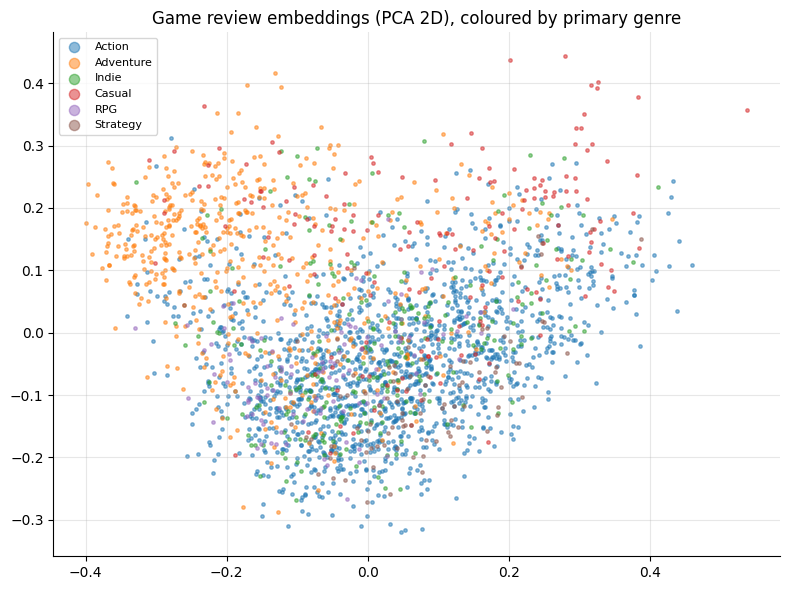

In [6]:
# PCA 2D projection coloured by the most common primary genres
# PCA 2D проекция, окрашенная по самым частым основным жанрам
coords = PCA(n_components=2, random_state=42).fit_transform(game_emb)
top6 = pd.Series(prim_arr)[pd.Series(prim_arr) != ""].value_counts().head(6).index

plt.figure(figsize=(8, 6))
for g in top6:
    sel = prim_arr == g
    plt.scatter(coords[sel, 0], coords[sel, 1], s=6, alpha=0.5, label=g)
plt.legend(markerscale=3, fontsize=8)
plt.title("Game review embeddings (PCA 2D), coloured by primary genre")
plt.tight_layout()
plt.show()

## Semantic Embedding Recommender

Same retrieval idea as the Genre/Tag Content-Based model, but in the learned semantic space: a user profile is the (L2-normalized) mean of the embeddings of their train games, and games are ranked by cosine similarity. Only the **item representation** changes — the user profile stays a simple mean, so any gain is attributable to the embeddings.

## Модель Semantic Embedding

Та же идея retrieval, что и в Genre/Tag Content-Based, но в выученном семантическом пространстве: профиль юзера — (L2-нормированное) среднее эмбеддингов его train-игр, игры ранжируются по cosine. Меняется только **представление айтемов** — профиль юзера остаётся простым средним, поэтому любой прирост объясняется именно эмбеддингами.

In [7]:
K = 10
sem = SemanticEmbeddingRecommender(game_emb, game_ids).fit(train)
sem_result = evaluate(sem, train, test, k=K)
print(sem_result)

{'Recall@10': 0.0728388755812315, 'MAP@10': 0.028502426550677574, 'NDCG@10': 0.03877825387043404}


## Benchmark Comparison

We re-evaluate the classical baselines on the same split and add the semantic model, so the table is self-contained.

## Сравнение с бенчмарком

Перезапускаем классические baseline на том же split и добавляем семантическую модель, чтобы таблица была самодостаточной.

                         Recall@10  MAP@10  NDCG@10
Popularity                  0.1224  0.0407   0.0595
Genre/Tag Content-Based     0.0471  0.0190   0.0255
ALS                         0.1343  0.0594   0.0769
Semantic Embedding          0.0728  0.0285   0.0388


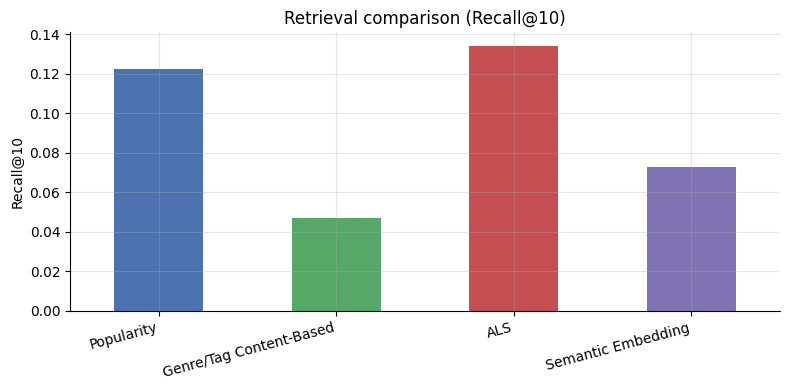

In [8]:
# Re-run classical baselines + semantic model on the same split
# Перезапускаем классические baseline + семантическую модель на том же split
results = {}
results["Popularity"] = evaluate(PopularityRecommender().fit(train), train, test, k=K)
results["Genre/Tag Content-Based"] = evaluate(
    ContentBasedRecommender(games, genre_weight=2).fit(train), train, test, k=K)
results["ALS"] = evaluate(
    ALSRecommender(factors=128, iterations=25, regularization=0.05).fit(train), train, test, k=K)
results["Semantic Embedding"] = sem_result

benchmark = pd.DataFrame(results).T[[f"Recall@{K}", f"MAP@{K}", f"NDCG@{K}"]].round(4)
print(benchmark.to_string())

fig, ax = plt.subplots(figsize=(8, 4))
benchmark[f"Recall@{K}"].plot.bar(ax=ax, color=["#4C72B0", "#55A868", "#C44E52", "#8172B3"])
ax.set_ylabel(f"Recall@{K}")
ax.set_title(f"Retrieval comparison (Recall@{K})")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

## Benchmark Summary

| Stage | Best Model |
|---|---|
| Classical Retrieval | ALS |
| Semantic Retrieval | Semantic Embedding |

Classical Retrieval relies on explicit metadata such as genres and tags. Semantic Retrieval replaces sparse metadata with dense review embeddings, allowing recommendations based on gameplay semantics rather than manually defined features. Although semantic retrieval improves over the genre/tag baseline, collaborative filtering (ALS) remains stronger because it learns directly from collective user behaviour.

## Сводка бенчмарка

| Этап | Лучшая модель |
|---|---|
| Classical Retrieval | ALS |
| Semantic Retrieval | Semantic Embedding |

Classical Retrieval опирается на явные метаданные — жанры и теги. Semantic Retrieval заменяет разреженные метаданные плотными эмбеддингами отзывов, позволяя рекомендовать на основе семантики геймплея, а не заданных вручную признаков. Хотя семантический retrieval улучшает результат относительно genre/tag baseline, коллаборативная фильтрация (ALS) остаётся сильнее, поскольку учится напрямую из коллективного поведения пользователей.

## Discussion

The qualitative check confirms the semantic space is meaningful: nearest neighbours of a game are clearly related titles (Counter-Strike → other shooters, Stardew Valley → farming and life sims, DOOM → fast FPS games), and average cosine similarity is higher within the same genre than across genres.

The Semantic Embedding model clearly outperforms the Genre/Tag Content-Based baseline. Review text captures gameplay concepts that are not explicitly represented by genres and tags, leading to a more informative item representation.

However, semantic similarity alone cannot model collaborative user behaviour, which explains why ALS remains the strongest retrieval model at this stage: content similarity finds games that are *similar*, not necessarily the game a user plays *next*.

This limitation motivates the next stage of the project, where user and item representations are learned jointly from interaction data instead of being manually aggregated.

## Обсуждение

Качественная проверка подтверждает, что семантическое пространство осмысленно: ближайшие соседи игры — явно родственные тайтлы (Counter-Strike → другие шутеры, Stardew Valley → фермерские и life-sim, DOOM → быстрые FPS), а средний cosine выше внутри одного жанра, чем между разными.

Модель Semantic Embedding заметно превосходит baseline Genre/Tag Content-Based. Текст отзывов улавливает игровые концепции, которые не выражены явно жанрами и тегами, что даёт более информативное представление айтема.

Однако одно семантическое сходство не моделирует коллаборативное поведение пользователей — поэтому на этом этапе ALS остаётся сильнейшей retrieval-моделью: контентное сходство находит *похожие* игры, а не обязательно ту, в которую пользователь сыграет *следующей*.

Это ограничение мотивирует следующий этап проекта, где представления пользователей и игр учатся совместно из данных о взаимодействиях, а не агрегируются вручную.

## Next Step

The next notebook replaces manually aggregated user profiles with trainable user and item towers that jointly learn an embedding space from interaction data. Item content (genres, tags, review embeddings) and user history are projected into a shared space, with FAISS for fast candidate retrieval.

## Следующий этап

Следующий ноутбук заменяет вручную агрегированные профили пользователей на обучаемые user- и item-башни, которые совместно учат пространство эмбеддингов из данных о взаимодействиях. Контент айтема (жанры, теги, эмбеддинги отзывов) и история пользователя проецируются в общее пространство, с FAISS для быстрого поиска кандидатов.